# 인천광역시 5대 범죄율과 가로등 관계 분석

인천광역시 군구별 5대 범죄 발생 비율과 가로등 지표의 상관관계를 확인합니다. 포트폴리오 재현성을 위해 필요한 데이터를 노트북 안에 정리했습니다.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
installed_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in installed_fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])

,강도,강간.강제추행,절도,폭력,가로등
강도,1.000,0.064,0.086,-0.123,-0.196
강간.강제추행,0.064,1.000,0.885,0.889,0.565
절도,0.086,0.885,1.000,0.916,0.760
폭력,-0.123,0.889,0.916,1.000,0.816
가로등,-0.196,0.565,0.760,0.816,1.000


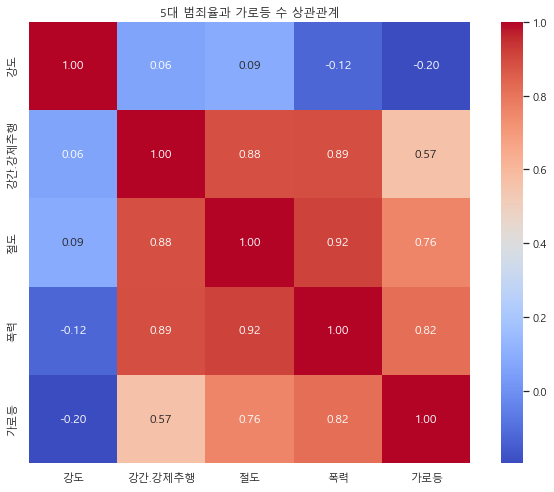

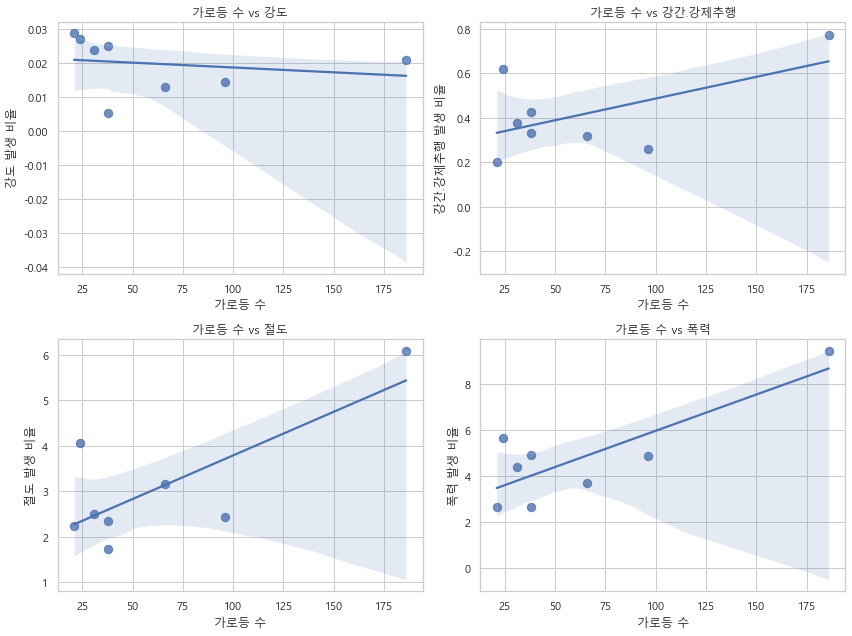

In [2]:
data_factor = {
    '군구': ['연수구', '계양구', '서구', '부평구', '미추홀구', '남동구', '중구', '강화군'],
    '가로등': [66, 31, 38, 21, 24, 38, 186, 96]
}
df_factor = pd.DataFrame(data_factor)
factor_column = '가로등'
factor_label = '가로등 수'
data_crime_rate = {
    '군구': ['중구', '미추홀구', '남동구', '부평구', '서구', '계양구', '강화군', '연수구'],
    '살인': [0.006962, 0.017179, 0.015435, 0.002054, 0.009002, 0.010145, 0.028697, 0.012832],
    '강도': [0.020886, 0.026996, 0.025083, 0.028761, 0.005401, 0.023672, 0.014348, 0.012832],
    '강간.강제추행': [0.772802, 0.620913, 0.329942, 0.201329, 0.428535, 0.378767, 0.258275, 0.318239],
    '절도': [6.084952, 4.0568, 1.724962, 2.237219, 2.337138, 2.492424, 2.439269, 3.169559],
    '폭력': [9.405916, 5.639762, 2.656906, 2.652203, 4.893946, 4.372734, 4.835492, 3.695681]
}
df_crime_rate = pd.DataFrame(data_crime_rate)

merged_df = pd.merge(df_factor, df_crime_rate, on='군구')
crime_columns = ['강도', '강간.강제추행', '절도', '폭력']

corr = merged_df[crime_columns + [factor_column]].corr()
display(corr.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title(f'5대 범죄율과 {factor_label} 상관관계')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
axes = axes.flatten()

for ax, crime in zip(axes, crime_columns):
    sns.regplot(data=merged_df, x=factor_column, y=crime, ax=ax, scatter_kws={'s': 70})
    ax.set_title(f'{factor_label} vs {crime}')
    ax.set_xlabel(factor_label)
    ax.set_ylabel(f'{crime} 발생 비율')

plt.tight_layout()
plt.show()